# Check adicional: ¿puede el modelo predecir una temporada futura?

Este notebook responde una pregunta adicional pedida por el profesor,
separada del entregable principal (notebook 01): ¿un modelo entrenado con
los datos de una temporada de la Champions League puede predecir
razonablemente los resultados de la temporada siguiente?

**Diseño de la prueba:**
- **Entrenamiento:** temporada 2023-2024 (125 partidos, fase de grupos de
  32 equipos).
- **Prueba:** temporada 2024-2025 (189 partidos, nueva fase de liga de 36
  equipos), usando ÚNICAMENTE estadísticas de equipo calculadas con datos
  de 2023-2024 (congeladas, sin actualizar con información de
  2024-2025), para simular un escenario real donde la temporada a
  predecir todavía no existe.

**Limitación conocida de acceso a datos:** el plan gratuito de la API de
football-data.org no permite consultar temporadas anteriores a 2023-2024
para esta competencia (se confirmó con pruebas reales, error 403), por lo
que solo se puede hacer un corte temporal en vez de usar varias
temporadas históricas de entrenamiento.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

from src.extract_api_football_data import fetch_matches

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
df_train_raw = fetch_matches(season=2023)
df_test_raw = fetch_matches(season=2024)

print("2023-2024 (entrenamiento):", len(df_train_raw), "partidos")
print("2024-2025 (prueba):", len(df_test_raw), "partidos")
print(df_train_raw["status"].value_counts())
print(df_test_raw["status"].value_counts())

2023-2024 (entrenamiento): 125 partidos
2024-2025 (prueba): 189 partidos
status
FINISHED    125
Name: count, dtype: int64
status
FINISHED    189
Name: count, dtype: int64


In [3]:
def calcular_stats_equipo(df):
    filas = []
    for _, row in df.iterrows():
        filas.append({"team": row["home_team"], "goles_favor": row["home_score"], "goles_contra": row["away_score"],
                       "resultado": "W" if row["home_score"] > row["away_score"] else ("D" if row["home_score"] == row["away_score"] else "L")})
        filas.append({"team": row["away_team"], "goles_favor": row["away_score"], "goles_contra": row["home_score"],
                       "resultado": "W" if row["away_score"] > row["home_score"] else ("D" if row["away_score"] == row["home_score"] else "L")})
    largo = pd.DataFrame(filas)

    stats = largo.groupby("team").agg(
        partidos=("resultado", "count"),
        prom_goles_favor=("goles_favor", "mean"),
        prom_goles_contra=("goles_contra", "mean"),
    )
    stats["win_rate"] = largo.groupby("team")["resultado"].apply(lambda s: (s == "W").mean())
    return stats

stats_2023 = calcular_stats_equipo(df_train_raw)
print("Equipos con estadísticas de 2023-2024:", len(stats_2023))
stats_2023.sort_values("win_rate", ascending=False).head(10)

Equipos con estadísticas de 2023-2024: 32


,partidos,prom_goles_favor,prom_goles_contra,win_rate
team,,,,
Manchester City FC,10,3.100000,1.700000,0.800000
Real Madrid CF,13,2.461538,1.384615,0.769231
FC Porto,8,2.250000,1.625000,0.625000
Club Atlético de Madrid,10,2.600000,1.500000,0.600000
FC Barcelona,10,2.000000,1.400000,0.600000
FC Bayern München,12,1.750000,1.083333,0.583333
Borussia Dortmund,13,1.307692,0.846154,0.538462
SS Lazio,8,1.000000,1.250000,0.500000
FK Shakhtar Donetsk,6,1.666667,2.000000,0.500000


In [4]:
equipos_test = set(df_test_raw["home_team"]).union(set(df_test_raw["away_team"]))
equipos_train = set(stats_2023.index)

con_historial = equipos_test & equipos_train
sin_historial = equipos_test - equipos_train

print("Equipos en 2024-2025:", len(equipos_test))
print("Con estadísticas de 2023-2024:", len(con_historial))
print("SIN estadísticas de 2023-2024:", len(sin_historial))
print(sorted(sin_historial))

Equipos en 2024-2025: 36
Con estadísticas de 2023-2024: 19
SIN estadísticas de 2023-2024: 17
['AC Sparta Praha', 'AS Monaco FC', 'Aston Villa FC', 'Atalanta BC', 'Bayer 04 Leverkusen', 'Bologna FC 1909', 'Club Brugge KV', 'GNK Dinamo Zagreb', 'Girona FC', 'Juventus FC', 'Lille OSC', 'Liverpool FC', 'SK Sturm Graz', 'Sporting Clube de Portugal', 'Stade Brestois 29', 'VfB Stuttgart', 'ŠK Slovan Bratislava']


In [5]:
promedio_liga = stats_2023[["prom_goles_favor", "prom_goles_contra", "win_rate"]].mean()
print("Promedio de liga (fallback para equipos sin historial):")
print(promedio_liga)

def stats_de(equipo):
    if equipo in stats_2023.index:
        s = stats_2023.loc[equipo]
        return s["prom_goles_favor"], s["prom_goles_contra"], s["win_rate"], 1
    else:
        return promedio_liga["prom_goles_favor"], promedio_liga["prom_goles_contra"], promedio_liga["win_rate"], 0

Promedio de liga (fallback para equipos sin historial):
prom_goles_favor     1.478466
prom_goles_contra    1.657472
win_rate             0.349459
dtype: float64


In [6]:
def construir_features(df, usar_stats_fn):
    filas = []
    for _, row in df.iterrows():
        gf_h, gc_h, wr_h, hist_h = usar_stats_fn(row["home_team"])
        gf_a, gc_a, wr_a, hist_a = usar_stats_fn(row["away_team"])

        if row["home_score"] > row["away_score"]:
            resultado = "H"
        elif row["home_score"] == row["away_score"]:
            resultado = "D"
        else:
            resultado = "A"

        filas.append({
            "home_prom_gf": gf_h, "home_prom_gc": gc_h, "home_win_rate": wr_h, "home_tiene_historial": hist_h,
            "away_prom_gf": gf_a, "away_prom_gc": gc_a, "away_win_rate": wr_a, "away_tiene_historial": hist_a,
            "resultado": resultado,
        })
    return pd.DataFrame(filas)

def stats_de_train(equipo):
    s = stats_2023.loc[equipo]
    return s["prom_goles_favor"], s["prom_goles_contra"], s["win_rate"], 1

train_df = construir_features(df_train_raw, stats_de_train)
print(train_df["resultado"].value_counts())
train_df.head()

resultado
H    60
A    39
D    26
Name: count, dtype: int64


,home_prom_gf,home_prom_gc,home_win_rate,home_tiene_historial,away_prom_gf,away_prom_gc,away_win_rate,away_tiene_historial,resultado
0,0.833333,1.333333,0.333333,1,1.000000,1.166667,0.166667,1,D
1,1.166667,2.166667,0.166667,1,1.750000,1.500000,0.500000,1,A
2,1.000000,1.250000,0.500000,1,2.600000,1.500000,0.600000,1,D
3,1.500000,1.666667,0.333333,1,0.833333,2.500000,0.166667,1,H
4,1.583333,1.250000,0.416667,1,1.307692,0.846154,0.538462,1,H


In [7]:
test_df = construir_features(df_test_raw, stats_de)
print(test_df["resultado"].value_counts())
print("Partidos de prueba con al menos un equipo sin historial:",
      ((test_df["home_tiene_historial"] == 0) | (test_df["away_tiene_historial"] == 0)).sum())
test_df.head()

resultado
H    96
A    67
D    26
Name: count, dtype: int64
Partidos de prueba con al menos un equipo sin historial: 125


,home_prom_gf,home_prom_gc,home_win_rate,home_tiene_historial,away_prom_gf,away_prom_gc,away_win_rate,away_tiene_historial,resultado
0,1.166667,2.166667,0.166667,1,1.478466,1.657472,0.349459,0,A
1,1.478466,1.657472,0.349459,0,1.125000,1.625000,0.250000,1,H
2,1.478466,1.657472,0.349459,0,1.478466,1.657472,0.349459,0,H
3,1.750000,1.083333,0.583333,1,1.478466,1.657472,0.349459,0,H
4,2.461538,1.384615,0.769231,1,1.478466,1.657472,0.349459,0,H


In [8]:
from sklearn.preprocessing import LabelEncoder

features = ["home_prom_gf", "home_prom_gc", "home_win_rate", "home_tiene_historial",
            "away_prom_gf", "away_prom_gc", "away_win_rate", "away_tiene_historial"]

le = LabelEncoder()
y_train = le.fit_transform(train_df["resultado"])
X_train = train_df[features]

y_test = le.transform(test_df["resultado"])
X_test = test_df[features]

modelo = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="mlogloss")
modelo.fit(X_train, y_train)

print("Clases:", list(le.classes_))
print("Modelo entrenado con", len(X_train), "partidos de 2023-2024")

Clases: ['A', 'D', 'H']
Modelo entrenado con 125 partidos de 2023-2024


In [9]:
y_pred = modelo.predict(X_test)

accuracy_modelo = accuracy_score(y_test, y_pred)

# Línea base ingenua: predecir siempre la clase más común en el entrenamiento
clase_mas_comun = pd.Series(y_train).mode()[0]
y_pred_baseline = [clase_mas_comun] * len(y_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Exactitud del modelo XGBoost sobre 2024-2025: {accuracy_modelo:.3f}")
print(f"Exactitud de la línea base ingenua (predecir siempre '{le.classes_[clase_mas_comun]}'): {accuracy_baseline:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Exactitud del modelo XGBoost sobre 2024-2025: 0.386
Exactitud de la línea base ingenua (predecir siempre 'H'): 0.508

              precision    recall  f1-score   support

           A       0.57      0.25      0.35        67
           D       0.11      0.35      0.17        26
           H       0.59      0.49      0.53        96

    accuracy                           0.39       189
   macro avg       0.42      0.36      0.35       189
weighted avg       0.51      0.39      0.42       189



In [10]:
mask_con_historial = (test_df["home_tiene_historial"] == 1) & (test_df["away_tiene_historial"] == 1)

acc_con_historial = accuracy_score(y_test[mask_con_historial.values], y_pred[mask_con_historial.values])
acc_sin_historial_completo = accuracy_score(y_test[~mask_con_historial.values], y_pred[~mask_con_historial.values])

print(f"Partidos con historial completo (ambos equipos): {mask_con_historial.sum()}")
print(f"  Exactitud del modelo en ese subconjunto: {acc_con_historial:.3f}")
print(f"Partidos con al menos un equipo sin historial: {(~mask_con_historial).sum()}")
print(f"  Exactitud del modelo en ese subconjunto: {acc_sin_historial_completo:.3f}")

Partidos con historial completo (ambos equipos): 64
  Exactitud del modelo en ese subconjunto: 0.516
Partidos con al menos un equipo sin historial: 125
  Exactitud del modelo en ese subconjunto: 0.320


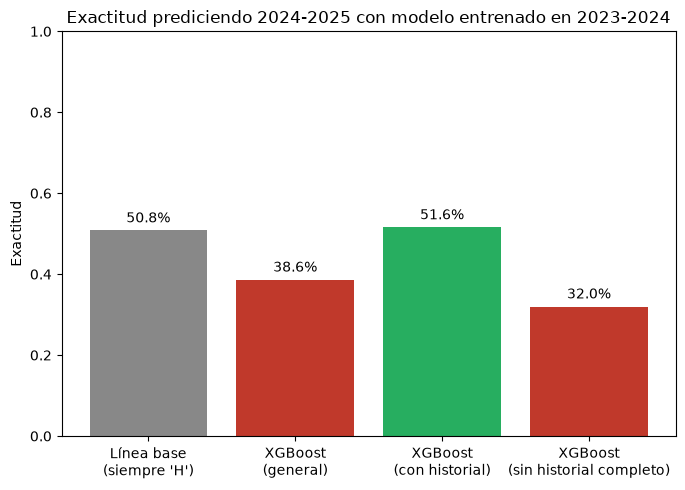

In [11]:
import matplotlib.pyplot as plt

etiquetas = ["Línea base\n(siempre 'H')", "XGBoost\n(general)", "XGBoost\n(con historial)", "XGBoost\n(sin historial completo)"]
valores = [accuracy_baseline, accuracy_modelo, acc_con_historial, acc_sin_historial_completo]

plt.figure(figsize=(7, 5))
barras = plt.bar(etiquetas, valores, color=["#888888", "#c0392b", "#27ae60", "#c0392b"])
plt.ylabel("Exactitud")
plt.title("Exactitud prediciendo 2024-2025 con modelo entrenado en 2023-2024")
plt.ylim(0, 1)
for barra, valor in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2, valor + 0.02, f"{valor:.1%}", ha="center")
plt.tight_layout()
plt.savefig("../docs/xgboost_2023_vs_2024_accuracy.png", dpi=150)
plt.show()

## Conclusión del check adicional

**Diseño:** se entrenó un XGBoost con los 125 partidos finalizados de la
temporada 2023-2024 (fase de grupos, 32 equipos), usando como variables
las estadísticas de cada equipo (promedio de goles a favor/en contra y
win rate) calculadas ÚNICAMENTE con esa temporada. Después se usaron esas
mismas estadísticas, congeladas, para predecir los 189 partidos de la
temporada 2024-2025 (nueva fase de liga, 36 equipos), sin permitir que el
modelo "viera" ningún dato de la temporada que intentaba predecir.

**Resultado principal:** el modelo obtuvo una exactitud de **38.6%**
sobre 2024-2025, por debajo de la línea base ingenua de predecir siempre
"gana el local" (**50.8%**). Es decir, en esta prueba el modelo **no
logró predecir mejor que el enfoque más simple posible**.

**Por qué probablemente pasó esto:**
- El cambio de formato del torneo (de 32 a 36 equipos en la fase de liga)
  hizo que **17 de los 36 equipos de 2024-2025 (47%) no tuvieran ningún
  historial en 2023-2024** dentro de esta competencia. A esos equipos se
  les asignó el promedio general de la liga como valor neutro, lo cual
  quita información real al modelo.
- Al separar los partidos, el modelo llegó a **51.6%** de exactitud en
  los 64 partidos donde ambos equipos sí tenían historial completo (muy
  cerca de la línea base), y cayó a **32.0%** en los 125 partidos con al
  menos un equipo sin historial. Esto sugiere que el problema principal
  no es que el enfoque sea inválido, sino la falta de datos suficientes:
  solo una temporada de entrenamiento (125 partidos) y casi la mitad de
  los equipos de prueba sin historial previo.

**Conclusión honesta:** con los datos y recursos disponibles (plan
gratuito de football-data.org, que solo permite acceder a las dos
temporadas más recientes de esta competencia), **no se puede afirmar que
el modelo prediga razonablemente una temporada futura a partir de una
sola temporada de entrenamiento**. El resultado es un hallazgo válido en
sí mismo: muestra que un modelo así necesitaría, como mínimo, más
temporadas de entrenamiento y